### 📦 CELL 1: Imports & GPU Setup


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy
from sklearn.metrics import f1_score, classification_report

# Setup Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")


✅ Using device: cuda:0


### 🗂️ CELL 2: Data Pipeline (Transforms & DataLoaders)

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import os

# The TRUE absolute path to the EuroSAT class folders
data_dir = 'data/eurosat/2750'

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# 1. Define separate transforms (Augmentation for train, strict evaluation for val)
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 2. Load the dataset twice (once for train transforms, once for val transforms)
full_train_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
full_val_dataset = datasets.ImageFolder(data_dir, transform=val_transform)

# 3. Create a locked random split so we compare ResNet vs EfficientNet fairly!
generator = torch.Generator().manual_seed(42)

train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# We take the train subset from the augmented dataset, and val subset from the clean dataset
train_subset, _ = random_split(full_train_dataset, [train_size, val_size], generator=generator)
_, val_subset = random_split(full_val_dataset, [train_size, val_size], generator=generator)

# 4. Build the final DataLoaders
dataloaders = {
    'train': DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2),
    'val': DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=2)
}

dataset_sizes = {'train': len(train_subset), 'val': len(val_subset)}
class_names = full_train_dataset.classes

print(f"✅ Dataset Successfully Split and Loaded!")
print(f"Train samples: {dataset_sizes['train']} | Val samples: {dataset_sizes['val']}")


✅ Dataset Successfully Split and Loaded!
Train samples: 22950 | Val samples: 4050


### 🧠 CELL 3: The Universal Training Loop

In [3]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs} | {"-" * 20}')

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model if it's the best one so far
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'✅ Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'🏆 Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model


### ⚙️ CELL 4: EfficientNet-B0 Setup & Training

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# 1. Load Pre-trained EfficientNet-B0
weights = EfficientNet_B0_Weights.DEFAULT
model_eff = efficientnet_b0(weights=weights)

# 2. Freeze the base feature extractor
for param in model_eff.features.parameters():
    param.requires_grad = False

# 3. Replace the Classifier Head
num_ftrs = model_eff.classifier[1].in_features
model_eff.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(num_ftrs, 10) # 10 EuroSAT classes
)
model_eff = model_eff.to(device)

# 4. Setup Optimizer & Scheduler
criterion = nn.CrossEntropyLoss()
# Only train the new classifier head!
optimizer_eff = optim.Adam(model_eff.classifier.parameters(), lr=0.001)
exp_lr_scheduler_eff = lr_scheduler.StepLR(optimizer_eff, step_size=5, gamma=0.1)

# 5. Print Architecture Size
total_params = sum(p.numel() for p in model_eff.parameters())
print(f"📊 EfficientNet-B0 Total Parameters: {total_params:,}")

# 6. BEGIN TRAINING
print("🚀 Launching Transfer Learning for EfficientNet-B0...")
model_eff = train_model(model_eff, dataloaders, criterion, optimizer_eff, exp_lr_scheduler_eff, num_epochs=15)

# 7. AUTOMATICALLY SAVE THE MODEL WEIGHTS
save_path = r'.\eurosat_efficientnet_b0_weights.pth'
torch.save(model_eff.state_dict(), save_path)

print(f"\n✅ Training Complete and Model Saved successfully to:")
print(f"   {save_path}")


📊 EfficientNet-B0 Total Parameters: 4,020,358
🚀 Launching Transfer Learning for EfficientNet-B0...
Epoch 1/15 | --------------------
Train Loss: 0.6311 Acc: 0.8261
Val Loss: 0.3111 Acc: 0.9030

Epoch 2/15 | --------------------
Train Loss: 0.3578 Acc: 0.8843
Val Loss: 0.2545 Acc: 0.9114

Epoch 3/15 | --------------------
Train Loss: 0.3281 Acc: 0.8916
Val Loss: 0.2333 Acc: 0.9178

Epoch 4/15 | --------------------
Train Loss: 0.3104 Acc: 0.8959
Val Loss: 0.2101 Acc: 0.9286

Epoch 5/15 | --------------------
Train Loss: 0.3007 Acc: 0.8983
Val Loss: 0.2044 Acc: 0.9291

Epoch 6/15 | --------------------
Train Loss: 0.2839 Acc: 0.9048
Val Loss: 0.2033 Acc: 0.9281

Epoch 7/15 | --------------------
Train Loss: 0.2799 Acc: 0.9041
Val Loss: 0.1979 Acc: 0.9306

Epoch 8/15 | --------------------
Train Loss: 0.2830 Acc: 0.9044
Val Loss: 0.2047 Acc: 0.9299

Epoch 9/15 | --------------------
Train Loss: 0.2801 Acc: 0.9029
Val Loss: 0.1982 Acc: 0.9286

Epoch 10/15 | --------------------
Train Loss:

### 📊 CELL 5: The Final Evaluation

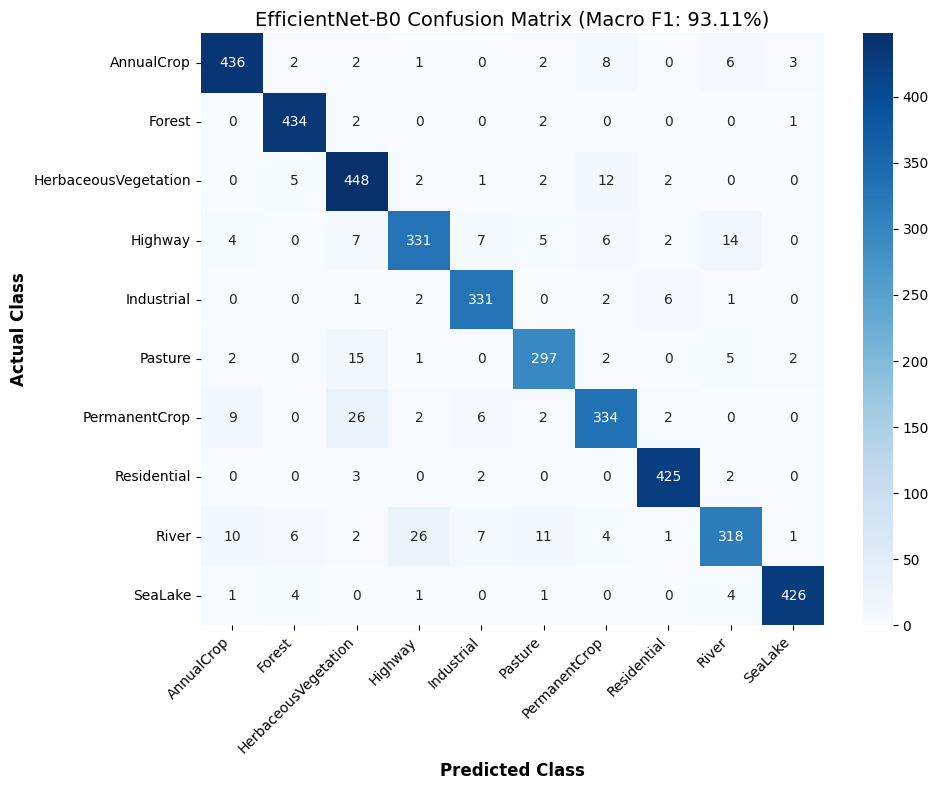

✅ Saved!


In [18]:
# Save the EfficientNet confusion matrix to disk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Class', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-B0 Confusion Matrix (Macro F1: 93.11%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

save_path = r'.\efficientnet_confusion_matrix.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved!")
